In [4]:
!pip install nuscenes-devkit

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 10.7 MB/s  0:00:03a 0:00:01m eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [nuscenes-devkit]━━ 8/9 [nuscenes-devkit]adless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.

In [10]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot='v1.0-mini', verbose=True)

# List all scenes to find the token
for scene in nusc.scene:
    print(f"Name: {scene['name']}, Token: {scene['token']}")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.263 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Name: scene-0061, Token: cc8c0bf57f984915a77078b10eb33198
Name: scene-0103, Token: fcbccedd61424f1b85dcbf8f897f9754
Name: scene-0553, Token: 6f83169d067343658251f72e1dd17dbc
Name: scene-0655, Token: bebf5f5b2a674631ab5c88fd1aa9e87a
Name: scene-0757, Token: 2fc3753772e241f2ab2cd16a784cc680
Name: scene-0796, Token: c5224b9b454b4ded9b5d2d2634bbda8a
Name: scene-0916, Token: 325cef682f064c55a255f2625c533b75
Name: scene-1077, Token: d25718445d89453381c659b9c8734939
Name: scene-1094, Token: de7d80a1f5fb4c3e82ce8a4f213b450a
Name: scene-1100, Token: e233467e827140efa4b42d2b4c435855


In [11]:
scene_token = 'cc8c0bf57f984915a77078b10eb33198'  # scene-0061's actual token
nusc.render_scene_channel(scene_token, 'CAM_FRONT')  # use token

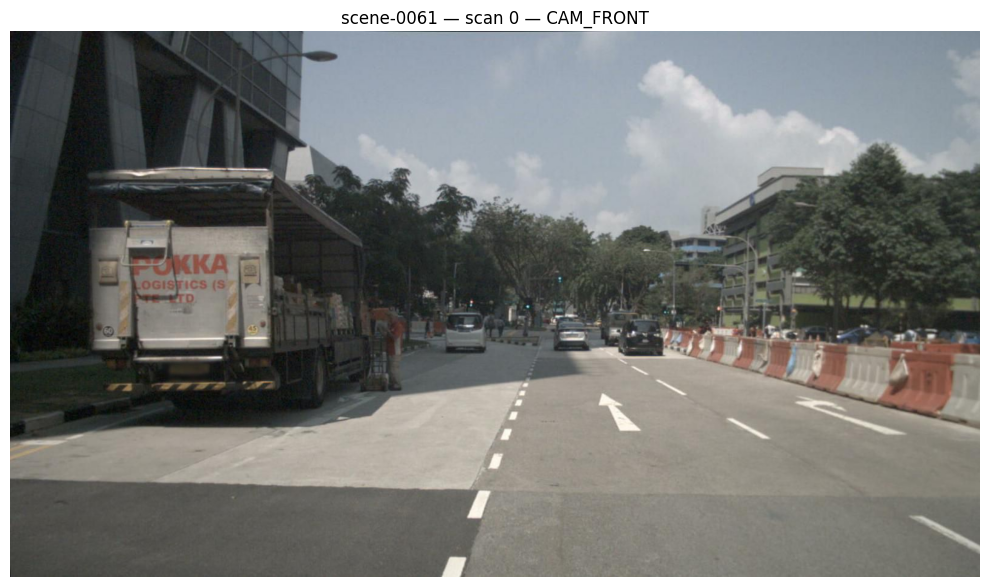

In [12]:
from nuscenes.nuscenes import NuScenes
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

nusc = NuScenes(version='v1.0-mini', dataroot='v1.0-mini', verbose=False)

# Get scene-0061
scene = next(s for s in nusc.scene if s['name'] == 'scene-0061')

# Get first sample (scan 0)
first_sample = nusc.get('sample', scene['first_sample_token'])

# Get CAM_FRONT data for that sample
cam_token = first_sample['data']['CAM_FRONT']
cam_data = nusc.get('sample_data', cam_token)

# Load and save the image
img_path = 'v1.0-mini/' + cam_data['filename']
img = mpimg.imread(img_path)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('scene-0061 — scan 0 — CAM_FRONT')
plt.tight_layout()
plt.savefig('output/scene0061_cam_front_scan0.png', dpi=150, bbox_inches='tight')
plt.show()